In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Ideal low pass filter function

In [36]:
def IHPF_filter(image, cuttof_frequency):
    height, width = image.shape
    filteredImg = np.zeros((height, width))

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u - height/2)**2 + (v - width/2)**2)
            if D > cuttof_frequency:
                filteredImg[u][v] = 1

    filteredImg = image * filteredImg
    filteredImg = np.fft.ifft2(np.fft.ifftshift(filteredImg))
    return np.abs(filteredImg)


### Gaussian high pass filter function

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [19]:
def gaussian_high_pass_filter(image, cuttof_frequency):
    filteredImg = image.copy()
    height, width = image.shape

    for u in range(height):
        for v in range(width):
            D = np.sqrt((u - height/2)**2 + (v - width/2)**2)
            filteredImg[u][v] = 1 - np.exp(-(D**2) / (2 * (cuttof_frequency**2)))

    filteredImg = image * filteredImg
    filteredImg = np.fft.ifft2(np.fft.ifftshift(filteredImg))
    return np.abs(filteredImg)

### Load original image

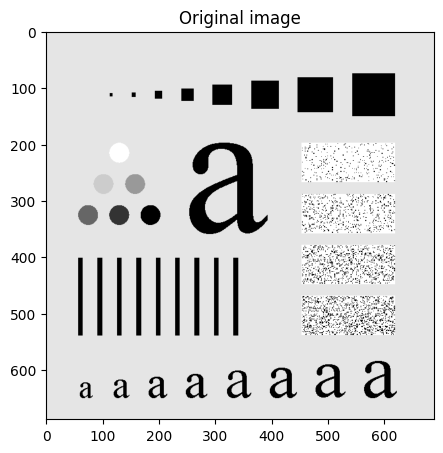

In [31]:
originalImg = cv2.imread('Characters Test Pattern 688x688.tif', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(5,10))
plt.title('Original image')
plt.imshow(originalImg, cmap='gray')
plt.show()


### Gaussian noisy image created

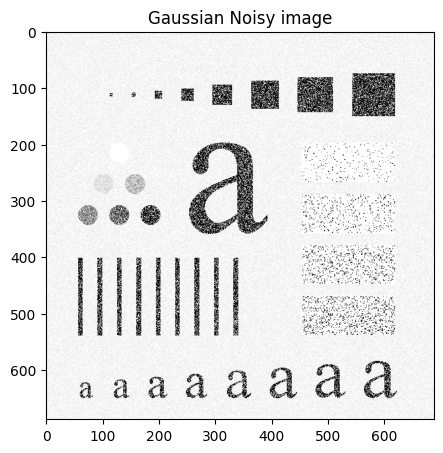

In [21]:
gaussian_noise = np.random.normal(7, 13, originalImg.shape).astype(np.uint8)
noisy_image = cv2.add(originalImg, gaussian_noise)

plt.figure(figsize=(5,10))
plt.title('Gaussian Noisy image')
plt.imshow(noisy_image, cmap='gray')
plt.show()

### Applying FFT on original image

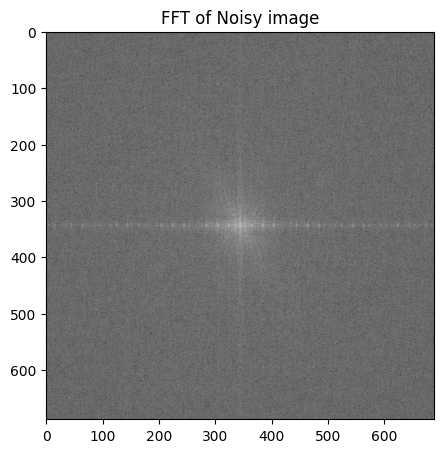

In [33]:
original_image_fft = np.fft.ifftshift(np.fft.fft2(originalImg))

plt.figure(figsize=(5,10))
plt.title('FFT of Noisy image')
plt.imshow(np.log(np.abs(noisy_image_fft)), cmap='gray')
plt.show()                            

### Applying FFT on noisy image

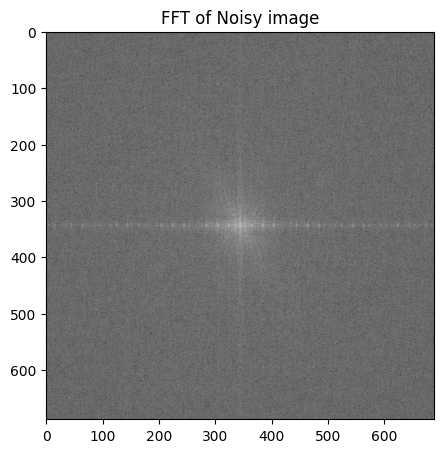

In [34]:
noisy_image_fft = np.fft.ifftshift(np.fft.fft2(noisy_image))

plt.figure(figsize=(5,10))
plt.title('FFT of Noisy image')
plt.imshow(np.log(np.abs(noisy_image_fft)), cmap='gray')
plt.show()                            

### Applying Ideal High Pass Filter for Edge Detection

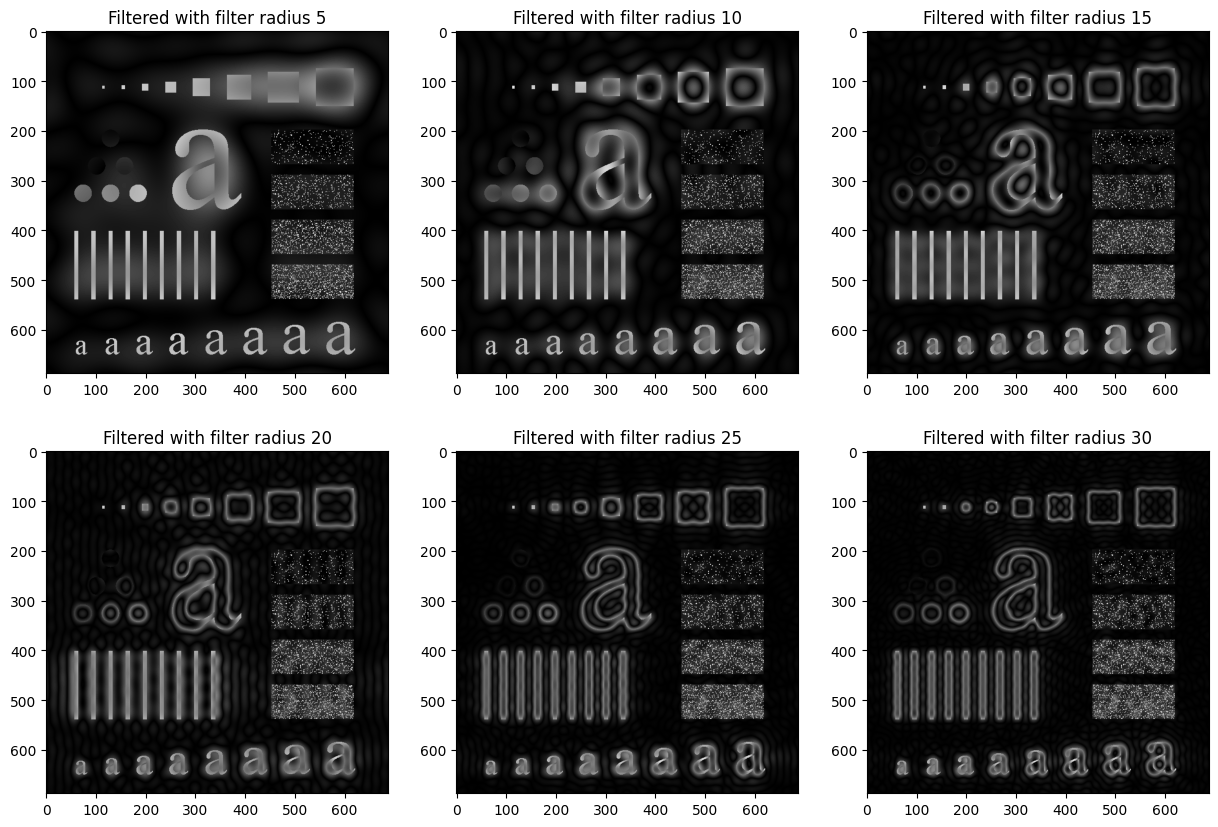

In [37]:
plt.figure(figsize=(15,10))
for r in range(1,7):
    filtered_image = IHPF_filter(original_image_fft, r*5)
    plt.subplot(2, 3, r)
    plt.title(f'Filtered with filter radius {r*5}')
    plt.imshow(filtered_image, cmap='gray')
plt.show()                            

### Applying Ideal High Pass Filter To Noisy Image for Edge Detection

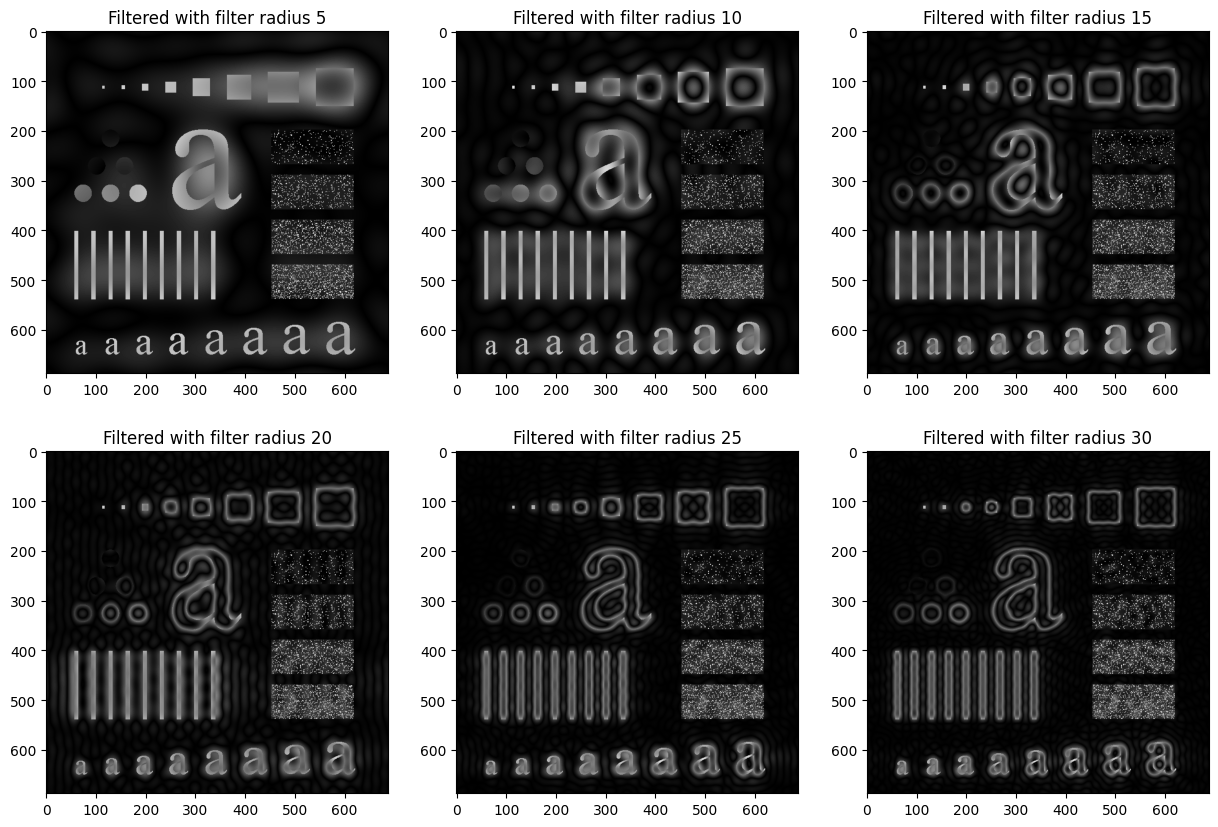

In [37]:
plt.figure(figsize=(15,10))
for r in range(1,7):
    filtered_image = IHPF_filter(original_image_fft, r*5)
    plt.subplot(2, 3, r)
    plt.title(f'Filtered with filter radius {r*5}')
    plt.imshow(filtered_image, cmap='gray')
plt.show()                            

### Applying Gaussian High Pass Filter for Edge Detection

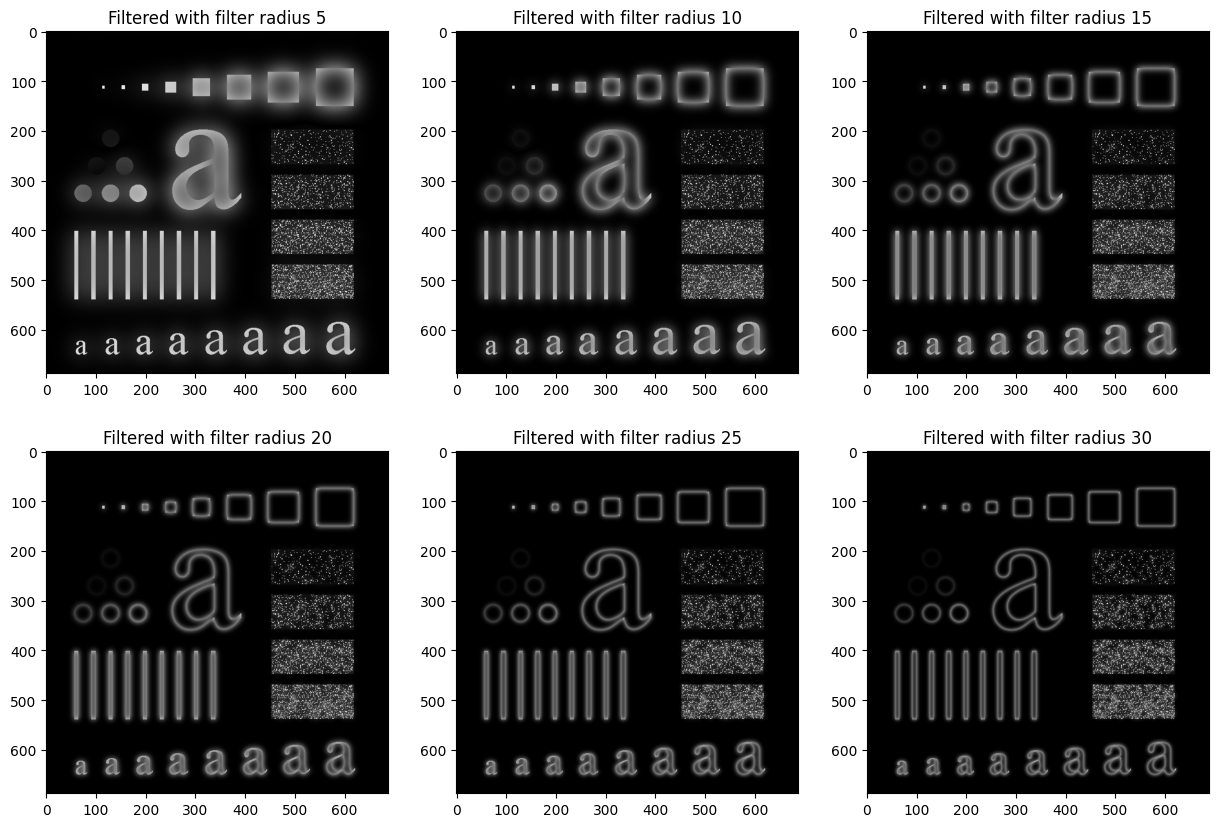

In [39]:
plt.figure(figsize=(15,10))
for r in range(1,7):
    filtered_image = gaussian_high_pass_filter(original_image_fft, r*5)
    plt.subplot(2, 3, r)
    plt.title(f'Filtered with filter radius {r*5}')
    plt.imshow(filtered_image, cmap='gray')
plt.show()                            

### Applying Gaussian High Pass Filter To Noisy Image for Edge Detection

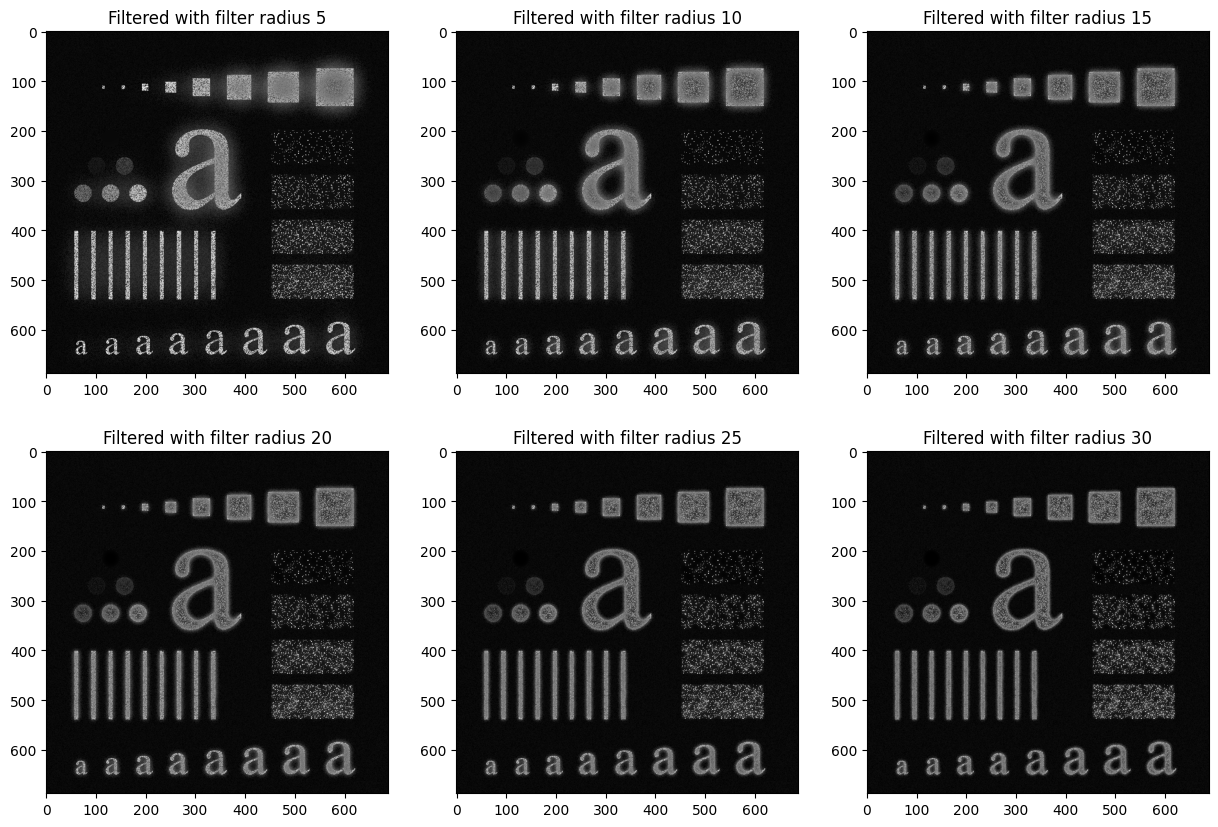

In [38]:
plt.figure(figsize=(15,10))
for r in range(1,7):
    filtered_image = gaussian_high_pass_filter(noisy_image_fft, r*5)
    plt.subplot(2, 3, r)
    plt.title(f'Filtered with filter radius {r*5}')
    plt.imshow(filtered_image, cmap='gray')
plt.show()                            